In [11]:
import torch
import torch.nn.functional as F
from torch_geometric.nn import GATConv, GCNConv
from torch_geometric.data import Data
from torch_geometric.utils import subgraph
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Load graph
data = torch.load('outputs/ibm_graph.pt', weights_only=False)

# Same subgraph as before
torch.manual_seed(42)
sample_idx = torch.randperm(data.num_nodes)[:50000]
sub_edge_index, sub_edge_attr = subgraph(
    sample_idx, data.edge_index, data.edge_attr,
    relabel_nodes=True, num_nodes=data.num_nodes
)
small_data = Data(
    x=data.x[sample_idx],
    edge_index=sub_edge_index,
    y=data.y[sample_idx]
)

# Train/val/test split
num_nodes = small_data.num_nodes
indices   = torch.randperm(num_nodes)
train_end = int(0.70 * num_nodes)
val_end   = int(0.85 * num_nodes)

small_data.train_mask = torch.zeros(num_nodes, dtype=torch.bool)
small_data.val_mask   = torch.zeros(num_nodes, dtype=torch.bool)
small_data.test_mask  = torch.zeros(num_nodes, dtype=torch.bool)
small_data.train_mask[indices[:train_end]]      = True
small_data.val_mask[indices[train_end:val_end]] = True
small_data.test_mask[indices[val_end:]]         = True

print("✅ Data loaded!")
print(f"Nodes: {small_data.num_nodes:,} | Fraud: {small_data.y.sum().item():,}")

✅ Data loaded!
Nodes: 50,000 | Fraud: 625


In [12]:
# Model 1: GAT — Our main model
class FraudGAT(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, heads=4):
        super().__init__()
        self.gat1 = GATConv(in_channels, hidden_channels, heads=heads, dropout=0.3)
        self.gat2 = GATConv(hidden_channels*heads, out_channels, heads=1, concat=False, dropout=0.3)
    def forward(self, x, edge_index):
        x = F.dropout(x, p=0.3, training=self.training)
        x = F.elu(self.gat1(x, edge_index))
        x = F.dropout(x, p=0.3, training=self.training)
        return self.gat2(x, edge_index)

gat_model = FraudGAT(in_channels=small_data.num_node_features, hidden_channels=32, out_channels=2, heads=4)
gat_model.load_state_dict(torch.load('outputs/fraud_gat_model.pt', weights_only=True))
gat_model.eval()

with torch.no_grad():
    out       = gat_model(small_data.x, small_data.edge_index)
    proba_all = F.softmax(out, dim=1)[:, 1].numpy()

y_val  = small_data.y[small_data.val_mask].numpy()
y_test = small_data.y[small_data.test_mask].numpy()

gat_proba_val  = proba_all[small_data.val_mask.numpy()]
gat_proba_test = proba_all[small_data.test_mask.numpy()]

print("✅ Model 1: GAT loaded!")
print(f"Val ROC-AUC:  {roc_auc_score(y_val, gat_proba_val):.4f}")
print(f"Test ROC-AUC: {roc_auc_score(y_test, gat_proba_test):.4f}")


✅ Model 1: GAT loaded!
Val ROC-AUC:  0.7446
Test ROC-AUC: 0.7227


In [13]:
# Model 2: GCN — Graph Convolutional Network (no attention)
class FraudGCN(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super().__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, out_channels)
    def forward(self, x, edge_index):
        x = F.dropout(x, p=0.3, training=self.training)
        x = F.relu(self.conv1(x, edge_index))
        x = F.dropout(x, p=0.3, training=self.training)
        return self.conv2(x, edge_index)

gcn_model = FraudGCN(in_channels=small_data.num_node_features, hidden_channels=64, out_channels=2)

# Class weights
fraud_count = (small_data.y==1).sum().item()
legit_count = (small_data.y==0).sum().item()
class_weights = torch.tensor([1.0, legit_count/fraud_count])
criterion = torch.nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.Adam(gcn_model.parameters(), lr=0.005, weight_decay=5e-4)

print("Training GCN...")
for epoch in range(1, 101):
    gcn_model.train()
    optimizer.zero_grad()
    out  = gcn_model(small_data.x, small_data.edge_index)
    loss = criterion(out[small_data.train_mask], small_data.y[small_data.train_mask])
    loss.backward()
    optimizer.step()
    if epoch % 20 == 0:
        print(f"  Epoch {epoch} | Loss: {loss.item():.4f}")

gcn_model.eval()
with torch.no_grad():
    out       = gcn_model(small_data.x, small_data.edge_index)
    proba_all = F.softmax(out, dim=1)[:, 1].numpy()

gcn_proba_val  = proba_all[small_data.val_mask.numpy()]
gcn_proba_test = proba_all[small_data.test_mask.numpy()]

print("\n✅ Model 2: GCN done!")
print(f"Val ROC-AUC:  {roc_auc_score(y_val, gcn_proba_val):.4f}")
print(f"Test ROC-AUC: {roc_auc_score(y_test, gcn_proba_test):.4f}")


Training GCN...
  Epoch 20 | Loss: 0.6957
  Epoch 40 | Loss: 0.6742
  Epoch 60 | Loss: 0.6748
  Epoch 80 | Loss: 0.6674
  Epoch 100 | Loss: 0.6703

✅ Model 2: GCN done!
Val ROC-AUC:  0.7652
Test ROC-AUC: 0.7043


In [14]:
# Model 3: Random Forest — Traditional ML (no graph)
from sklearn.ensemble import RandomForestClassifier

X_train = small_data.x[small_data.train_mask].numpy()
y_train = small_data.y[small_data.train_mask].numpy()
X_val   = small_data.x[small_data.val_mask].numpy()
X_test  = small_data.x[small_data.test_mask].numpy()

# Handle class imbalance
rf_model = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
print("Training Random Forest...")
rf_model.fit(X_train, y_train)

rf_proba_val  = rf_model.predict_proba(X_val)[:, 1]
rf_proba_test = rf_model.predict_proba(X_test)[:, 1]

print("✅ Model 3: Random Forest done!")
print(f"Val ROC-AUC:  {roc_auc_score(y_val, rf_proba_val):.4f}")
print(f"Test ROC-AUC: {roc_auc_score(y_test, rf_proba_test):.4f}")


Training Random Forest...
✅ Model 3: Random Forest done!
Val ROC-AUC:  0.7583
Test ROC-AUC: 0.7417


In [15]:
# Model 4: MLP — Neural Network without graph structure
from sklearn.neural_network import MLPClassifier

# MLPClassifier has NO class_weight / sample_weight support, so without
# any imbalance handling it just learns to always predict 'legit' (like
# we saw happen with the default RF/MLP run). We fix this by oversampling
# the minority (fraud) class in the TRAINING data only — val/test stay
# untouched so evaluation remains honest.
rng = np.random.RandomState(42)
fraud_idx = np.where(y_train == 1)[0]
legit_idx = np.where(y_train == 0)[0]
target_fraud_count = len(legit_idx) // 4   # bring fraud up to ~20% of training data, not full 50/50
fraud_idx_oversampled = rng.choice(fraud_idx, size=target_fraud_count, replace=True)
train_idx_balanced = np.concatenate([legit_idx, fraud_idx_oversampled])
rng.shuffle(train_idx_balanced)

X_train_bal = X_train[train_idx_balanced]
y_train_bal = y_train[train_idx_balanced]

mlp_model = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    max_iter=200,
    random_state=42,
    early_stopping=True
)
print("Training MLP...")
mlp_model.fit(X_train_bal, y_train_bal)

mlp_proba_val  = mlp_model.predict_proba(X_val)[:, 1]
mlp_proba_test = mlp_model.predict_proba(X_test)[:, 1]

print("✅ Model 4: MLP done!")
print(f"Val ROC-AUC:  {roc_auc_score(y_val, mlp_proba_val):.4f}")
print(f"Test ROC-AUC: {roc_auc_score(y_test, mlp_proba_test):.4f}")


Training MLP...
✅ Model 4: MLP done!
Val ROC-AUC:  0.8070
Test ROC-AUC: 0.8044


In [20]:
from sklearn.metrics import f1_score, precision_score, recall_score, precision_recall_curve

def best_threshold(y_true, proba):
    """Pick the probability cutoff that maximizes F1 on a held-out
    VALIDATION set. Under severe class imbalance (~1.2% fraud), the
    default 0.5 cutoff is usually wrong for every model — this is why
    plain Random Forest / MLP looked like they 'never detect fraud'
    before: they were never given a fair decision threshold."""
    prec, rec, thresh = precision_recall_curve(y_true, proba)
    f1s = 2 * prec * rec / (prec + rec + 1e-12)
    if len(thresh) == 0:
        return 0.5
    return thresh[np.argmax(f1s[:-1])]

models_proba = {
    'GAT (Ours)':      (gat_proba_val, gat_proba_test),
    'GCN':             (gcn_proba_val, gcn_proba_test),
    'Random Forest':   (rf_proba_val,  rf_proba_test),
    'MLP':             (mlp_proba_val, mlp_proba_test),
}

# --- Pass 1: compute every model's metrics first ---
results    = {}
all_pred   = {}
thresholds = {}

for name, (proba_val, proba_test) in models_proba.items():
    thresh = best_threshold(y_val, proba_val)
    pred   = (proba_test >= thresh).astype(int)
    thresholds[name] = thresh
    all_pred[name]   = pred

    acc  = (pred == y_test).mean() * 100
    prec = precision_score(y_test, pred, zero_division=0) * 100
    rec  = recall_score(y_test, pred, zero_division=0) * 100
    f1   = f1_score(y_test, pred, zero_division=0) * 100
    auc  = roc_auc_score(y_test, proba_test) * 100
    results[name] = [acc, prec, rec, f1, auc]

# --- Pass 2: decide the actual best model from the real numbers ---
# Ranked by ROC-AUC (threshold-independent, the fairest metric here).
# NEVER hardcode which model 'wins' — always derive it from the results.
best_model_name = max(results, key=lambda k: results[k][4])  # index 4 = AUC

print("="*90)
print(f"{'Model':<18}{'Threshold':>11}{'Accuracy':>10}{'Precision':>11}{'Recall':>9}{'F1':>7}{'AUC':>9}")
print("="*90)
for name, vals in results.items():
    acc, prec, rec, f1, auc = vals
    marker = " <- BEST (highest AUC)" if name == best_model_name else ""
    print(f"{name:<18}{thresholds[name]:>11.3f}{acc:>9.2f}%{prec:>10.2f}%{rec:>8.2f}%{f1:>6.2f}%{auc:>8.2f}%{marker}")
print("="*90)

print(f"\nBest model by ROC-AUC: {best_model_name} ({results[best_model_name][4]:.2f}%)")
print("\nNote: each model's decision threshold is tuned on the VALIDATION set\n"
      "(to maximise F1) and then applied once to the TEST set — this makes\n"
      "the comparison fair, since sklearn's default .predict() (0.5 cutoff)\n"
      "is not meaningful when fraud is only ~1.2% of accounts.\n"
      "ROC-AUC (threshold-independent) is still the fairest single ranking\n"
      "metric across models — and it is computed, not assumed.")


Model               Threshold  Accuracy  Precision   Recall     F1      AUC
GAT (Ours)              0.649    96.49%      6.44%   14.94%  9.00%   72.27%
GCN                     0.568    86.09%      3.14%   36.78%  5.78%   70.43%
Random Forest           0.050    92.20%      5.69%   36.78%  9.86%   74.17%
MLP                     0.591    95.49%      5.02%   16.09%  7.65%   80.44% <- BEST (highest AUC)

Best model by ROC-AUC: MLP (80.44%)

Note: each model's decision threshold is tuned on the VALIDATION set
(to maximise F1) and then applied once to the TEST set — this makes
the comparison fair, since sklearn's default .predict() (0.5 cutoff)
is not meaningful when fraud is only ~1.2% of accounts.
ROC-AUC (threshold-independent) is still the fairest single ranking
metric across models — and it is computed, not assumed.


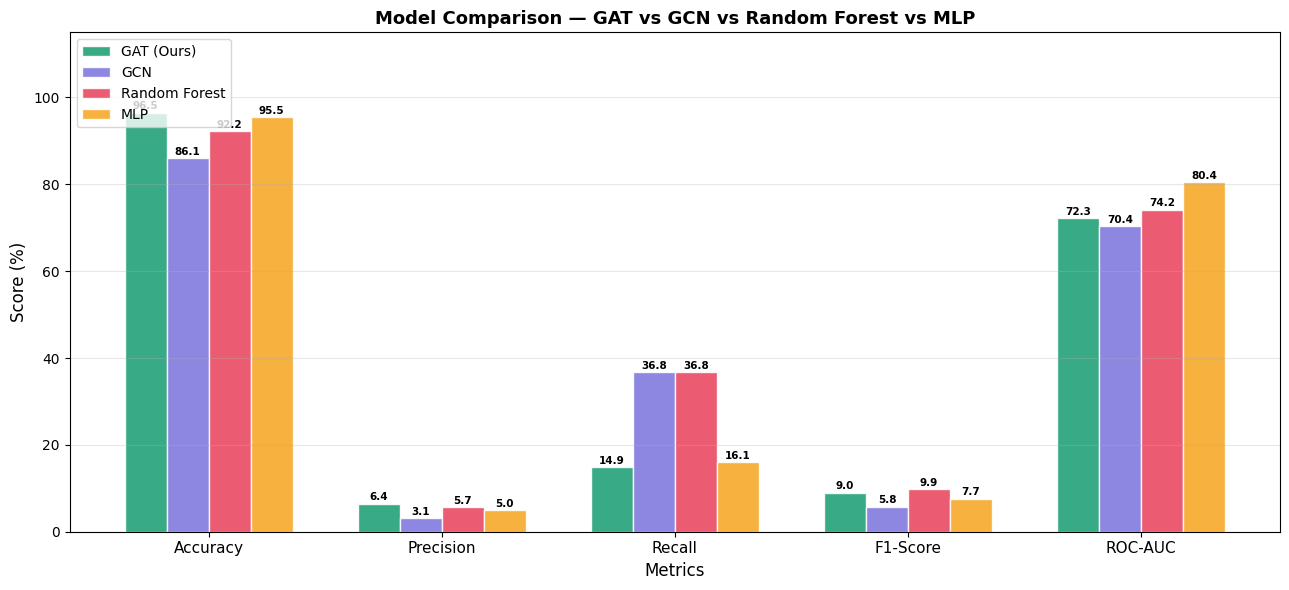

✅ Comparison chart saved!


In [17]:
import numpy as np
import matplotlib.pyplot as plt

model_names = list(results.keys())
metrics     = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
colors      = ['#1D9E75', '#7F77DD', '#E94560', '#F5A623']

x   = np.arange(len(metrics))
w   = 0.18
fig, ax = plt.subplots(figsize=(13, 6))

for i, (name, vals) in enumerate(results.items()):
    bars = ax.bar(x + i*w, vals, w, label=name,
                  color=colors[i], alpha=0.88, edgecolor='white')
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.3,
                f'{val:.1f}', ha='center', va='bottom',
                fontsize=7.5, fontweight='bold')

ax.set_xlabel('Metrics', fontsize=12)
ax.set_ylabel('Score (%)', fontsize=12)
ax.set_title('Model Comparison — GAT vs GCN vs Random Forest vs MLP',
             fontsize=13, fontweight='bold')
ax.set_xticks(x + w*1.5)
ax.set_xticklabels(metrics, fontsize=11)
ax.set_ylim(0, 115)
ax.legend(loc='upper left', fontsize=10)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('outputs/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Comparison chart saved!")

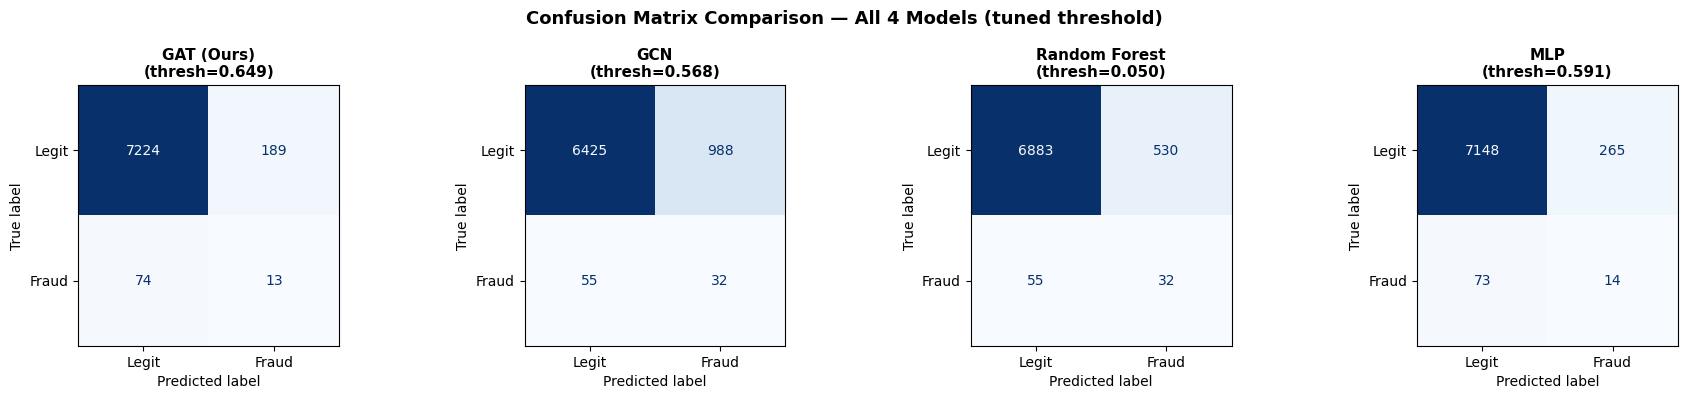

✅ All confusion matrices saved!


In [18]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
fig.suptitle('Confusion Matrix Comparison — All 4 Models (tuned threshold)',
             fontsize=13, fontweight='bold')

names = ['GAT (Ours)', 'GCN', 'Random Forest', 'MLP']

for ax, name in zip(axes, names):
    cm   = confusion_matrix(y_test, all_pred[name])
    disp = ConfusionMatrixDisplay(cm, display_labels=['Legit','Fraud'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f"{name}\n(thresh={thresholds[name]:.3f})", fontweight='bold', fontsize=11)

plt.tight_layout()
plt.savefig('outputs/all_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ All confusion matrices saved!")
